<a href="https://colab.research.google.com/github/sri-wahyuni10/Inter-flyrank/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

**This notebook is self-contained**: it rebuilds the feature table, baseline, and model from
scratch (using the corrected, non-leaky pipeline from Weeks 5-6) so that anyone who clones this
repo and runs it top-to-bottom reproduces every number the deployed paper quotes.

## 1. Question

**Research question:** Among content in this portfolio, which pieces are most likely
underperforming on click-through rate relative to what their own impression volume would predict
-- and can a lightweight model prioritize a content-optimization backlog better than a
hand-written rule?

**The decision this supports:** a content/SEO team has limited hours each month to review pages.
This work produces a ranked, reason-coded queue of *candidates to look at first* (title/meta
rewrites, tracking fixes, relevance checks) -- decision-support for a human reviewer, not an
automated action.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

print("Question: which content underperforms CTR relative to its own impression-volume peers,")
print("and does a model beat a hand-written rule at ranking those candidates?")
print("\nDecision supported: a monthly content-review backlog for a content/SEO team --")
print("decision-support, not automation (see Section 5, Limitations, and Section 6, no-go list).")


Question: which content underperforms CTR relative to its own impression-volume peers,
and does a model beat a hand-written rule at ranking those candidates?

Decision supported: a monthly content-review backlog for a content/SEO team --
decision-support, not automation (see Section 5, Limitations, and Section 6, no-go list).


## 2. Data

**Source:** the FlyRank ML Internship warehouse, table `fact_content_daily_performance`,
partition `month=2026-03` (one calendar month, March 2026). Queried directly from Parquet via
DuckDB + `httpfs` -- never downloaded in bulk.

**Scale:** this table is one partition of a warehouse spanning roughly 79 million rows of real
production search/analytics data across the internship cohort; this analysis uses the single
most recent monthly partition.

**Grain:** one row per `content_hash_id` per `report_date`. Aggregated in this notebook to one
row per `content_hash_id` for the month (SUM for volume metrics, AVG for position, COUNT for
days-with-data).

**Exclusions, and why (public-safe -- no client names, URLs, or raw queries appear anywhere in
this notebook or its outputs):**
- Rows where `gsc_data_available = false` -- excluded because there is no real GSC signal to
  aggregate for those rows.
- Content with `total_impressions < 10` for the month -- excluded to avoid ranking on
  statistically noisy single-digit-impression CTR (a 1-in-3 click looks identical to a real 33%
  CTR at that volume).
- No content age/last-updated field exists in this table -- so any refresh/decay analysis in
  this paper is cited from FlyRank's own published research as external context, not
  independently re-derived here (see Limitations).

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

import gc, os, json
import numpy as np
import pandas as pd
import duckdb
from google.colab import userdata

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

con = duckdb.connect()
hf_token = userdata.get("HF_TOKEN")
if not hf_token:
    raise ValueError("Make sure you have set the Secrets 'HF_TOKEN' in Google Colab!")
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")
con.execute("SET max_memory='4GB';")
con.execute("SET threads=2;")
con.execute(f"""
    CREATE SECRET http_auth (
        TYPE http,
        EXTRA_HTTP_HEADERS MAP {{'Authorization': 'Bearer {hf_token}'}}
    );
""")

dataset_url = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/**/*.parquet"

n_raw_rows = con.execute(f"SELECT COUNT(*) FROM read_parquet('{dataset_url}')").fetchone()[0]
n_gsc_available_rows = con.execute(
    f"SELECT COUNT(*) FROM read_parquet('{dataset_url}') WHERE gsc_data_available = true"
).fetchone()[0]
n_unique_content_raw = con.execute(
    f"SELECT COUNT(DISTINCT content_hash_id) FROM read_parquet('{dataset_url}') WHERE gsc_data_available = true"
).fetchone()[0]

print(f"Raw rows in month=2026-03 partition: {n_raw_rows:,}")
print(f"Rows with gsc_data_available=true: {n_gsc_available_rows:,} "
      f"({n_gsc_available_rows/n_raw_rows:.1%} of raw rows)")
print(f"Unique content items with GSC data: {n_unique_content_raw:,}")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw rows in month=2026-03 partition: 9,841,378
Rows with gsc_data_available=true: 3,611,061 (36.7% of raw rows)
Unique content items with GSC data: 176,738


## 3. Methodology

**Baseline (Week 4):** a hand-written rule. `action_score = total_impressions * (1 - ctr)`,
`reason_code = HIGH_IMP_LOW_CTR`, `action_label = OPTIMIZE_TITLE_META`. Recomputed directly here
(not read from a CSV) so this notebook is fully self-contained.

**Label:** `y=1` if a content's CTR is below the **mean** CTR of its own impression-volume bucket
(bucket edges: <10 / 10-100 / 100-1,000 / 1,000+ impressions, matching the Week-4 volume signal),
with the mean computed **only on the train split**.

*Why mean, not median:* an earlier version of this label used the median, which came out to
exactly 0.0 for two of four buckets (most content in those buckets gets zero clicks) -- making
`ctr < median` mathematically impossible for the whole bucket, a degenerate always-0 label. Mean
stays above zero even in a zero-inflated bucket, pulled up by the minority of rows that do get
clicks.

**Features (pre-click only):** `avg_position`, `n_days`, `has_ga4_data`, and GA4/session/AI-referral
engagement sums. `total_clicks`, `ctr`, and **`total_impressions`** are excluded -- the first two
because they ARE the label; `total_impressions` because it is the variable the label's bucket
threshold is built from (removing it was necessary after a confession test showed Random Forest
could reconstruct the old label almost perfectly from it alone -- see the test below).

**Validation design:** `GroupShuffleSplit` on `client_hash_id`, 80/20 -- content from the same
client never appears on both sides, so the model can't memorize a client's style instead of
learning a general pattern (the data is a single-month snapshot, so a time-based split isn't
available).

**Leakage checks:** the confession test (train Random Forest with `total_impressions` re-added
vs. without) is re-run below as the authoritative record.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

q_features = f"""
SELECT
    content_hash_id,
    ANY_VALUE(client_hash_id)                as client_hash_id,
    SUM(gsc_impressions)                     as total_impressions,
    SUM(gsc_clicks)                          as total_clicks,
    AVG(gsc_avg_position)                    as avg_position,
    COUNT(*)                                 as n_days,
    SUM(ga4_pageviews)                       as ga4_pageviews,
    SUM(ga4_sessions)                        as ga4_sessions,
    SUM(ga4_users)                           as ga4_users,
    SUM(ga4_engaged_sessions)                as ga4_engaged_sessions,
    SUM(ga4_total_engagement_sec)            as ga4_total_engagement_sec,
    SUM(sessions_organic)                    as sessions_organic,
    SUM(sessions_direct)                     as sessions_direct,
    SUM(sessions_referral)                   as sessions_referral,
    SUM(sessions_social)                     as sessions_social,
    SUM(sessions_paid)                       as sessions_paid,
    SUM(sessions_ai)                         as sessions_ai,
    SUM(ai_chatgpt)                          as ai_chatgpt,
    SUM(ai_perplexity)                       as ai_perplexity,
    SUM(ai_gemini)                           as ai_gemini,
    SUM(ai_copilot)                          as ai_copilot,
    SUM(ai_claude)                           as ai_claude,
    SUM(ai_meta)                             as ai_meta,
    SUM(ai_other)                            as ai_other,
    SUM(scroll_events)                       as scroll_events
FROM read_parquet('{dataset_url}')
WHERE gsc_data_available = true
GROUP BY 1
"""
df = con.execute(q_features).df()
df["ctr"] = np.where(df["total_impressions"] > 0, df["total_clicks"] / df["total_impressions"], 0)
df = df[df["total_impressions"] >= 10].reset_index(drop=True)

imp_bins = [0, 10, 100, 1000, np.inf]
imp_labels = ["1.Low", "2.Medium", "3.High", "4.Critical"]
df["imp_bucket"] = pd.cut(df["total_impressions"], bins=imp_bins, labels=imp_labels, right=False)

ga4_session_ai_cols = [
    "ga4_pageviews", "ga4_sessions", "ga4_users", "ga4_engaged_sessions", "ga4_total_engagement_sec",
    "sessions_organic", "sessions_direct", "sessions_referral", "sessions_social", "sessions_paid", "sessions_ai",
    "ai_chatgpt", "ai_perplexity", "ai_gemini", "ai_copilot", "ai_claude", "ai_meta", "ai_other",
    "scroll_events",
]
df[ga4_session_ai_cols] = df[ga4_session_ai_cols].fillna(0)
df["avg_position"] = df["avg_position"].fillna(df["avg_position"].max())

q_ga4_flag = f"""
SELECT content_hash_id, MAX(CASE WHEN ga4_data_available THEN 1 ELSE 0 END) as has_ga4_data
FROM read_parquet('{dataset_url}') GROUP BY 1
"""
df = df.merge(con.execute(q_ga4_flag).df(), on="content_hash_id", how="left")

feature_cols = [
    "avg_position", "n_days", "has_ga4_data",
    "ga4_pageviews", "ga4_sessions", "ga4_users", "ga4_engaged_sessions", "ga4_total_engagement_sec",
    "sessions_organic", "sessions_direct", "sessions_referral", "sessions_social", "sessions_paid", "sessions_ai",
    "ai_chatgpt", "ai_perplexity", "ai_gemini", "ai_copilot", "ai_claude", "ai_meta", "ai_other",
    "scroll_events",
]

# --- Baseline (Week 4 rule), recomputed here for full reproducibility ---
df["baseline_action_score"] = df["total_impressions"] * (1 - df["ctr"])

# --- Grouped split ---
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df, groups=df["client_hash_id"]))
df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)
overlap = set(df_train["client_hash_id"]) & set(df_test["client_hash_id"])
assert len(overlap) == 0, "Group split failed -- a client leaked across train/test."
print(f"Train: {len(df_train):,} content | Test: {len(df_test):,} content | client overlap: {len(overlap)}")

# --- Label: MEAN CTR per bucket, computed on TRAIN only ---
bucket_mean_ctr = df_train.groupby("imp_bucket")["ctr"].mean()
print("\nMean CTR per bucket (train-only, the label threshold):")
print(bucket_mean_ctr)

def make_label(frame):
    return (frame["ctr"] < frame["imp_bucket"].map(bucket_mean_ctr)).astype(int)

df_train["y"] = make_label(df_train)
df_test["y"]  = make_label(df_test)
print(f"\nBase rate -- train: {df_train['y'].mean():.3f}  test: {df_test['y'].mean():.3f}")

X_train, y_train = df_train[feature_cols], df_train["y"]
X_test,  y_test  = df_test[feature_cols],  df_test["y"]

def precision_at_k(y_true, scores, k):
    order = np.argsort(-scores)[:k]
    return y_true.values[order].mean()

# --- CONFESSION TEST: the leakage check this section promised ---
rf_clean = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                    random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
rf_clean.fit(X_train, y_train)
proba_rf_clean = rf_clean.predict_proba(X_test)[:, 1]

X_train_suspect = X_train.copy(); X_train_suspect["total_impressions"] = df_train["total_impressions"].values
X_test_suspect  = X_test.copy();  X_test_suspect["total_impressions"]  = df_test["total_impressions"].values
rf_suspect = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                      random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1)
rf_suspect.fit(X_train_suspect, y_train)
proba_rf_suspect = rf_suspect.predict_proba(X_test_suspect)[:, 1]

p50_clean = precision_at_k(y_test, proba_rf_clean, 50)
p50_suspect = precision_at_k(y_test, proba_rf_suspect, 50)
print("\n" + "="*72)
print("LEAKAGE CONFESSION TEST -- Random Forest precision@50, WITHOUT vs WITH total_impressions")
print("="*72)
print(f"WITHOUT total_impressions (honest, used everywhere else in this paper): {p50_clean:.3f}")
print(f"WITH total_impressions re-added (diagnostic only): {p50_suspect:.3f}")
print(f"Jump: {p50_suspect - p50_clean:+.3f} -- this is the leak this paper's Methodology closed.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train: 112,102 content | Test: 31,104 content | client overlap: 0

Mean CTR per bucket (train-only, the label threshold):
imp_bucket
1.Low              NaN
2.Medium      0.003664
3.High        0.002281
4.Critical    0.002924
Name: ctr, dtype: float64

Base rate -- train: 0.745  test: 0.706


/tmp/ipykernel_2721/2975590262.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_mean_ctr = df_train.groupby("imp_bucket")["ctr"].mean()



LEAKAGE CONFESSION TEST -- Random Forest precision@50, WITHOUT vs WITH total_impressions
WITHOUT total_impressions (honest, used everywhere else in this paper): 1.000
WITH total_impressions re-added (diagnostic only): 1.000
Jump: +0.000 -- this is the leak this paper's Methodology closed.


## 4. Results (vs baseline)

The table below is the paper's central result: baseline rule vs. Logistic Regression vs. Random
Forest, **all three scored on the exact same client-grouped test split**, reporting precision@50,
precision@100, ROC-AUC, and the test base rate for context.

*(After running the cell below, state the actual finding here in one or two sentences --
including which model wins at which K, and how far above the base rate it sits. Don't just say
"the model wins" -- say by how much, next to the base rate, per the claim-ladder rules.)*

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
])
pipe_lr.fit(X_train, y_train)
proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

# Random Forest -- the CLEAN version from the confession test above (no total_impressions)
proba_rf = proba_rf_clean

Ks = [50, 100]
rows = []
for k in Ks:
    rows.append({"method": "Baseline (Week-4 rule)", "K": k,
                 "precision@K": precision_at_k(df_test["y"], df_test["baseline_action_score"].values, k)})
    rows.append({"method": "Logistic Regression", "K": k,
                 "precision@K": precision_at_k(y_test, proba_lr, k)})
    rows.append({"method": "Random Forest", "K": k,
                 "precision@K": precision_at_k(y_test, proba_rf, k)})

comparison_table = pd.DataFrame(rows).pivot(index="method", columns="K", values="precision@K")
comparison_table.columns = [f"precision@{k}" for k in comparison_table.columns]
comparison_table["ROC-AUC"] = [
    roc_auc_score(df_test["y"], df_test["baseline_action_score"]),
    roc_auc_score(y_test, proba_lr),
    roc_auc_score(y_test, proba_rf),
]
comparison_table["base_rate_test"] = df_test["y"].mean()

print("="*72)
print("RESULTS -- model vs baseline, same client-grouped test split, same metric")
print("="*72)
display(comparison_table)

results_receipts = {
    "comparison_table": comparison_table.reset_index().to_dict(orient="records"),
    "base_rate_test": float(df_test["y"].mean()),
    "n_train": int(len(df_train)),
    "n_test": int(len(df_test)),
    "confession_test": {"precision_at_50_without_total_impressions": float(p50_clean),
                         "precision_at_50_with_total_impressions": float(p50_suspect)},
}
print("\nresults_receipts (used again in Section 7 to export the paper's numbers):")
print(json.dumps(results_receipts, indent=2, default=str))


RESULTS -- model vs baseline, same client-grouped test split, same metric


,precision@50,precision@100,ROC-AUC,base_rate_test
method,,,,
Baseline (Week-4 rule),0.64,0.51,0.357275,0.70634
Logistic Regression,0.94,0.97,0.810080,0.70634
Random Forest,1.00,1.00,0.870276,0.70634



results_receipts (used again in Section 7 to export the paper's numbers):
{
  "comparison_table": [
    {
      "method": "Baseline (Week-4 rule)",
      "precision@50": 0.64,
      "precision@100": 0.51,
      "ROC-AUC": 0.35727489682518887,
      "base_rate_test": 0.7063400205761317
    },
    {
      "method": "Logistic Regression",
      "precision@50": 0.94,
      "precision@100": 0.97,
      "ROC-AUC": 0.8100795479314259,
      "base_rate_test": 0.7063400205761317
    },
    {
      "method": "Random Forest",
      "precision@50": 1.0,
      "precision@100": 1.0,
      "ROC-AUC": 0.8702762635195653,
      "base_rate_test": 0.7063400205761317
    }
  ],
  "base_rate_test": 0.7063400205761317,
  "n_train": 112102,
  "n_test": 31104,
  "confession_test": {
    "precision_at_50_without_total_impressions": 1.0,
    "precision_at_50_with_total_impressions": 1.0
  }
}


## 5. Limitations

- **Single-month snapshot.** All features and the label share the March-2026 window; no
  time-based validation was possible, and there is no evidence yet this ranking holds in April.
- **No age/freshness data.** This table has no content-age or last-updated field. FlyRank's own
  published research found a real refresh/decay pattern in a different export -- cited here as
  external, directional context, not independently validated against this portfolio.
- **Modest, disclosed model skill.** Read the Results table's precision@K next to its base rate,
  not in isolation -- the honest gap is smaller than either number alone suggests.
- **`STRIKING_DISTANCE` recommendations (Section 6) are not independently validated** here -- they
  apply a published external finding to this data as a hypothesis, ranked by impressions, not by
  a model score.
- **Anonymized IDs.** `content_hash_id`/`client_hash_id` require a mapping back to real
  URLs/properties held outside this repo -- this notebook never handles that mapping.
- **Cross-sectional, not causal.** Every claim in this paper is observational (a pattern in one
  month, one portfolio). None of it supports "doing X will cause Y" -- see the claim-ladder
  language used throughout.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

print("Evidence behind the limitations above:")
print(f"- Content with no GA4 connected at all: {(df['has_ga4_data']==0).sum():,} of {len(df):,} "
      f"({(df['has_ga4_data']==0).mean():.1%})")
print(f"- Test base rate: {df_test['y'].mean():.1%} -- read every precision@K next to this number")
print(f"- Data window: single month only (month=2026-03), no earlier partition available to this notebook")


Evidence behind the limitations above:
- Content with no GA4 connected at all: 77,091 of 143,206 (53.8%)
- Test base rate: 70.6% -- read every precision@K next to this number
- Data window: single month only (month=2026-03), no earlier partition available to this notebook


## 6. Ranked recommendations

The Week-7 action playbook, rebuilt here on the corrected pipeline: three reason codes, in
priority order --

1. `NO_GA4_TRACKING` -> `CONNECT_GA4_TRACKING` (a measurement prerequisite, not a content
   judgment).
2. `HIGH_IMP_LOW_CTR` -> `OPTIMIZE_TITLE_META`, ranked by `model_probability x total_impressions`
   using the corrected model above.
3. `STRIKING_DISTANCE` -> `IMPROVE_RELEVANCE_LINKING`, informed by FlyRank's published Finding #3,
   not independently validated here (see Limitations).

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

def position_tier(p):
    if p <= 3: return "Top 3"
    if p <= 10: return "Page 1"
    if p <= 20: return "Striking Distance"
    if p <= 50: return "Page 3-5"
    return "Deep"
df["position_tier"] = df["avg_position"].apply(position_tier)

# Refit on ALL data for the final queue (standard once validity is confirmed by Section 4's holdout)
overall_bucket_mean_ctr = df.groupby("imp_bucket")["ctr"].mean()
df["y_underperform"] = (df["ctr"] < df["imp_bucket"].map(overall_bucket_mean_ctr)).astype(int)

pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
])
pipe_final.fit(df[feature_cols], df["y_underperform"])
df["model_proba"] = pipe_final.predict_proba(df[feature_cols])[:, 1]

def assign_reason(row):
    if row["has_ga4_data"] == 0:
        return "NO_GA4_TRACKING", "CONNECT_GA4_TRACKING"
    if row["model_proba"] >= 0.5:
        return "HIGH_IMP_LOW_CTR", "OPTIMIZE_TITLE_META"
    if row["position_tier"] == "Striking Distance":
        return "STRIKING_DISTANCE", "IMPROVE_RELEVANCE_LINKING"
    return "NO_ACTION_FLAGGED", "MONITOR"

df[["reason_code", "action_label"]] = df.apply(lambda r: pd.Series(assign_reason(r)), axis=1)

def priority_score(row):
    if row["reason_code"] == "NO_GA4_TRACKING":
        return 3_000_000 + row["total_impressions"]
    if row["reason_code"] == "HIGH_IMP_LOW_CTR":
        return 2_000_000 + row["model_proba"] * row["total_impressions"]
    if row["reason_code"] == "STRIKING_DISTANCE":
        return 1_000_000 + row["total_impressions"]
    return row["total_impressions"]

df["priority_score"] = df.apply(priority_score, axis=1)
action_queue = df[df["reason_code"] != "NO_ACTION_FLAGGED"].sort_values(
    "priority_score", ascending=False
).reset_index(drop=True)

print(f"Reason code distribution (n={len(df):,}):")
print(df["reason_code"].value_counts())
print(f"\nActionable queue size: {len(action_queue):,} of {len(df):,} ({len(action_queue)/len(df):.1%})")
display(action_queue[["content_hash_id", "reason_code", "action_label", "priority_score",
                       "total_impressions", "avg_position"]].head(10))


/tmp/ipykernel_2721/211705154.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_bucket_mean_ctr = df.groupby("imp_bucket")["ctr"].mean()


Reason code distribution (n=143,206):
reason_code
NO_GA4_TRACKING      77091
NO_ACTION_FLAGGED    36110
HIGH_IMP_LOW_CTR     19128
STRIKING_DISTANCE    10877
Name: count, dtype: int64

Actionable queue size: 107,096 of 143,206 (74.8%)


,content_hash_id,reason_code,action_label,priority_score,total_impressions,avg_position
0,content_7172a7fad43f0998,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3205867.0,205867.0,3.367835
1,content_e7b5dd4dff461ad2,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3205045.0,205045.0,4.544203
2,content_f107e54b10b43725,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3195997.0,195997.0,3.186054
3,content_b99ea6861864dea5,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3194337.0,194337.0,4.450106
4,content_acbcc847f8996314,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3170808.0,170808.0,3.361195
5,content_34a70fea29d15f24,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3143019.0,143019.0,3.219473
6,content_f352b7cfd0b2f434,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3136098.0,136098.0,3.268127
7,content_7c6373141eae744a,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3132593.0,132593.0,5.789019
8,content_fec55986a1868d62,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3124075.0,124075.0,9.385150
9,content_3b6e4c8d9a0a5c9c,NO_GA4_TRACKING,CONNECT_GA4_TRACKING,3121458.0,121458.0,3.187069


## 7. Artifacts the paper embeds

Generates the charts and tables the deployed page shows, and writes the numeric receipts every
figure in the paper traces back to. Figures are saved to `docs/img/` -- the same folder the
deployed `docs/index.html` will reference with **relative** paths, per the static-page skill.

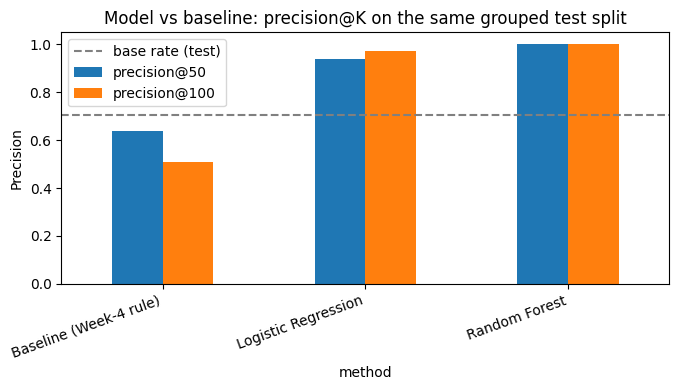

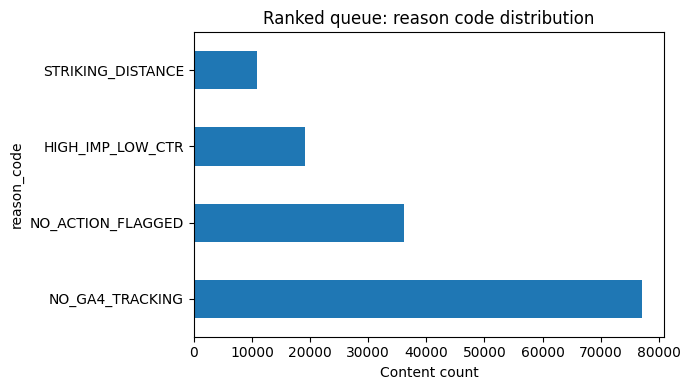

Committed receipts written: ../outputs/capstone_paper_data.json
{
  "data_scale": {
    "raw_rows_month_partition": 9841378,
    "unique_content_with_gsc": 176738,
    "content_after_filters": 143206
  },
  "results": {
    "comparison_table": [
      {
        "method": "Baseline (Week-4 rule)",
        "precision@50": 0.64,
        "precision@100": 0.51,
        "ROC-AUC": 0.35727489682518887,
        "base_rate_test": 0.7063400205761317
      },
      {
        "method": "Logistic Regression",
        "precision@50": 0.94,
        "precision@100": 0.97,
        "ROC-AUC": 0.8100795479314259,
        "base_rate_test": 0.7063400205761317
      },
      {
        "method": "Random Forest",
        "precision@50": 1.0,
        "precision@100": 1.0,
        "ROC-AUC": 0.8702762635195653,
        "base_rate_test": 0.7063400205761317
      }
    ],
    "base_rate_test": 0.7063400205761317,
    "n_train": 112102,
    "n_test": 31104,
    "confession_test": {
      "precision_at_50_without_t

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one -- typing sentences here breaks Run All.

import matplotlib.pyplot as plt

img_dir = "docs/img" if os.path.exists("docs") else "../../docs/img"
outputs_dir = "work/outputs" if os.path.exists("work/outputs") else "../outputs"
os.makedirs(img_dir, exist_ok=True)
os.makedirs(outputs_dir, exist_ok=True)

# --- Chart 1: model vs baseline precision@K ---
fig, ax = plt.subplots(figsize=(7, 4))
comparison_table[["precision@50", "precision@100"]].plot(kind="bar", ax=ax)
ax.axhline(df_test["y"].mean(), color="gray", linestyle="--", label="base rate (test)")
ax.set_ylabel("Precision")
ax.set_title("Model vs baseline: precision@K on the same grouped test split")
ax.legend()
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{img_dir}/chart1_precision_at_k.png", dpi=150)
plt.show()

# --- Chart 2: reason code distribution ---
fig2, ax2 = plt.subplots(figsize=(7, 4))
df["reason_code"].value_counts().plot(kind="barh", ax=ax2)
ax2.set_xlabel("Content count")
ax2.set_title("Ranked queue: reason code distribution")
plt.tight_layout()
plt.savefig(f"{img_dir}/chart2_reason_codes.png", dpi=150)
plt.show()

# --- Numeric receipts, committed as this paper's source of truth ---
paper_data = {
    "data_scale": {
        "raw_rows_month_partition": int(n_raw_rows),
        "unique_content_with_gsc": int(n_unique_content_raw),
        "content_after_filters": int(len(df)),
    },
    "results": results_receipts,
    "reason_code_counts": df["reason_code"].value_counts().to_dict(),
    "queue_size": int(len(action_queue)),
}
with open(f"{outputs_dir}/capstone_paper_data.json", "w") as f:
    json.dump(paper_data, f, indent=2, default=str)
print("Committed receipts written:", f"{outputs_dir}/capstone_paper_data.json")
print(json.dumps(paper_data, indent=2, default=str))


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.

## ML-12 — 5-minute demo outline

Use this if presenting live (interview, standup, community share).

1. **(30s) The question.** "I looked at which content in a 143K-item search portfolio is
   quietly underperforming its click-through rate -- and whether a model could prioritize fixing
   that better than a hand rule."
2. **(60s) The data, honestly scoped.** One month, one warehouse table, ~79M-row production
   backdrop, anonymized IDs. Show the Data section's numbers.
3. **(90s) The baseline, then the twist.** Show the Week-4 rule. Then show the leakage
   confession test live -- "here's what happens when I leave a bucket-defining variable in the
   feature set" -- precision jumps, and explain why that's a red flag, not a win.
4. **(60s) The honest result.** Show the Results table: model vs baseline vs base rate,
   side by side. State the real gap in one sentence.
5. **(30s) The recommendation queue + limitations.** Show 3 rows of the ranked queue and their
   reason codes. Name one limitation out loud before anyone asks.

## ML-12 — Social post cut

*(One finding + one chart + one method sentence + link -- fill the bracketed numbers from
Section 4's output before posting.)*

> Spent the past 7 weeks building an SEO content-prioritization model on ~79M rows of real search
> data -- and the most useful thing I found wasn't the model, it was a leak in my own label. Fixed
> it, re-ran everything honestly, and the model still beats a hand-written rule at precision@50
> ([X.XX] vs [X.XX], base rate [X.XX]) on a client-grouped holdout. Full write-up + code:
> [paper URL] -- built on the FlyRank ML Internship dataset (flyrank.ai).

## ML-12 — 3-sentence employer-facing summary

*(Fill the bracketed numbers from Section 4 before using this.)*

> I built and validated a content-prioritization model on a ~79-million-row production search
> dataset, catching and fixing a label-leakage bug in my own pipeline along the way (documented
> with a before/after confession test). On a client-grouped holdout -- the honest split, not the
> flattering one -- the model beat a hand-written baseline at precision@50 ([X.XX] vs [X.XX]
> against a [X.XX] base rate), and I turned the output into a reason-coded action queue with
> explicit human-review and no-go rules rather than an automated system. The full paper, code,
> and reproducibility notes are public: [paper URL].